# This is an 2D implementation of the Quickhull Algorithm in Python.

**This algorithm is used to find the convex hull of a set of points in a plane. It works by recursively dividing the point set into two subsets and finding the convex hull for each subset**

In [240]:
# Import Python Modules
import matplotlib.pyplot as plt
import numpy as np
import math
import random

In [241]:
# Create points for quickhull implementation
n_points = 10
points = [(random.random(), random.random()) for _ in range(n_points)]

print(points)

x = [p[0] for p in points]
y = [p[1] for p in points]


[(0.7365592768610866, 0.20258902875721807), (0.9395606225952914, 0.627912472944561), (0.3455749341593507, 0.02293448029912315), (0.4588226985154973, 0.3092243641601532), (0.06897461507481206, 0.034547033402668514), (0.4014530631943981, 0.2552328173744284), (0.8786207312396948, 0.8416194811135317), (0.5569883192828659, 0.7201389520895864), (0.21554236050717623, 0.030505173992151136), (0.4925301056645409, 0.9313809571285502)]


In [242]:

def perpendicular_distance(p1, p2, p):
    """
    Finds the distance from point p to the line that joins through points p1, p2. This is the determinant of the vectors

    Arguments:
        p1 -- point 1 [x1, y1]
        p2 -- point 2 [x2, y2]
        p  -- point to find distance to line [x, y]

    Return: Distance from point p to the line through p1 and p2
    """
    return (p[1] - p1[1]) * (p2[0] - p1[0]) - (p2[1] - p1[1]) * (p[0] - p1[0])
    

In [243]:
def find_outside_points(p1, p2, points):
        """
        Finds the points that outside the convex hull.
        Arguments:
            p1 -- point 1 [x1, y1]
            p2 -- point 2 [x2, y2]
            points -- list of points [[x1, y1], [x2, y2], ...]

        Return: A list of points that are outside the convex hull.
        """
        if not points:
            return []
        farthest_point = max(points, key=lambda p: abs(perpendicular_distance(p1, p2, p)))
        #Get rightmost points
        points1 = [p for p in points if perpendicular_distance(p1, farthest_point, p) > 0]
        #Get leftmost points
        points2 = [p for p in points if perpendicular_distance(farthest_point, p2, p) > 0]
        return find_outside_points(p1, farthest_point, points1) + [farthest_point] + find_outside_points(farthest_point, p2, points2)

In [244]:
def sort_points(points):
    """
    This sorts the convex hull points in a counter clockwise position to make sure the plot draws the convex hull accurately. This does not impact the quickhull algorithm in anyway,
    it is for visualisation on the graph
    
    Arguments:
        points - [(x1, y1), (x2, y2), ...] - The points from the convex hull
    Return: A list of points sorted in counter clockwise order
    """
    
    if len(points) <= 1:
        return points
    
    #Find the point closest to the centroid out of all the points to focus on
    centroid_x = sum(p[0] for p in points) / len(points)
    centroid_y = sum(p[1] for p in points) / len(points)

    def angle_from_centroid(point):
        #Calculating the angle between the point and the centroid, it does this for both centroids on each axis
        return math.atan2(point[1] - centroid_y, point[0] - centroid_x)
    return sorted(points, key=angle_from_centroid)

In [245]:
# Quickhull Algorithm Implementation
def quickhull(points):
    """
    Quickhull algorithm to find the convex hull of a set of points in a 2D space.
    Arguments:
        points -- list of points [(x1, y1), (x2, y2), ...]
    Return: A list of points that represent the convex hull.
    """
    
    # Base Case
    if len(points) <= 2:
        return(points)
    
    min_point = min(points)
    max_point = max(points)
    hull = find_outside_points(min_point, max_point, points) + find_outside_points(max_point, min_point, points)
    return sort_points(set(hull))
    

The number of points processed is: 6


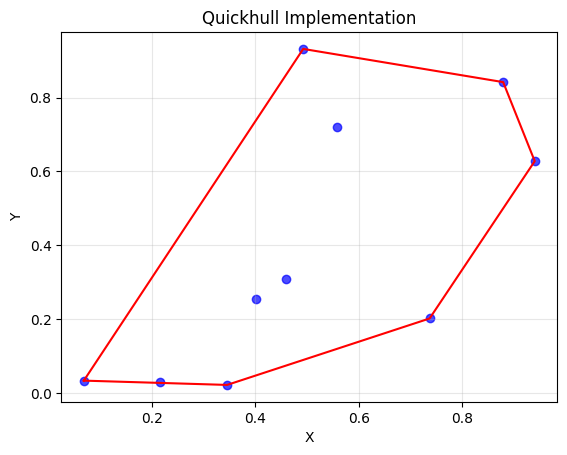

In [246]:
#Plotting the Convex Hull with all the points
convex_hull = quickhull(points)
convex_x = [p[0] for p in convex_hull]
convex_y = [p[1] for p in convex_hull]
convex_x.append(convex_x[0])
convex_y.append(convex_y[0])
print("The number of points processed is: " + str(len(convex_hull)))

plt.scatter([p[0] for p in points], [p[1] for p in points], alpha = 0.7, color = "blue")
plt.plot(convex_x, convex_y, color = "red")
plt.title("Quickhull Implementation")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha = 0.3)
plt.show()     

**The code below highlights the instances where the Quickhull algorithm may not perform well or as expected.**

*When every point is a point on the convex hull, it will have the worst time complexity, as every single point will need to computed. In instances with a high number of points, a recursion error will happen as the recursion stack is too high.*

In [247]:
#Creating circle points for quickhull implementation to show that the algorithm may struggle with certain distributions of points.
n_points = 60000
angles = np.linspace(0, 2 * np.pi, n_points)
circle_points = [(np.cos(a), np.sin(a)) for a in angles]

The number of points processed is: 60000


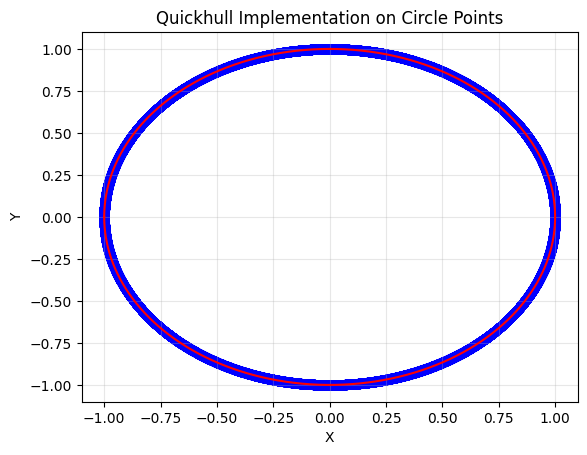

In [248]:
#Plotting the Convex Hull with circle points
convex_hull = quickhull(circle_points)
convex_x = [p[0] for p in convex_hull]
convex_y = [p[1] for p in convex_hull]
convex_x.append(convex_x[0])
convex_y.append(convex_y[0])
print("The number of points processed is: " + str(len(convex_hull)))

plt.scatter([p[0] for p in circle_points], [p[1] for p in circle_points], alpha = 0.7, color = "blue")
plt.plot(convex_x, convex_y, color = "red")
plt.title("Quickhull Implementation on Circle Points")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha = 0.3)
plt.show()


*There is a large difference in the time taken for the execution of each code block despite there being the same number of points. The number of points checked by the algorithm is larger for the circle, as each point has to be checked.*

In [249]:
#Creating points for quickhull implementation to compare to circle points with same number of points.
n_points = 60000
points = [(random.random(), random.random()) for _ in range(n_points)]

random_x = [p[0] for p in points]
random_y = [p[1] for p in points]

The number of points processed is: 29


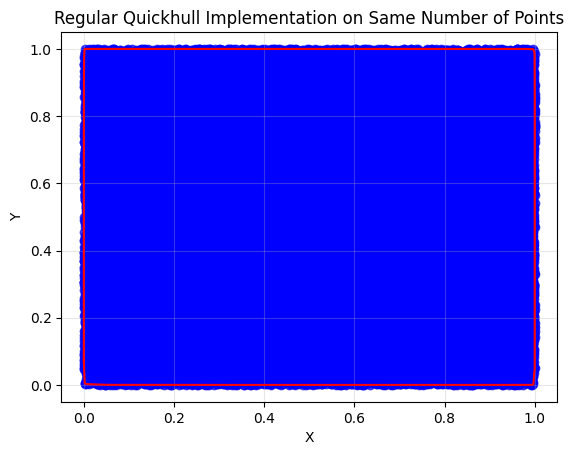

In [250]:

convex_hull = quickhull(points)
convex_x = [p[0] for p in convex_hull]
convex_y = [p[1] for p in convex_hull]
convex_x.append(convex_x[0])
convex_y.append(convex_y[0])
print("The number of points processed is: " + str(len(convex_hull)))
plt.scatter(random_x, random_y, alpha = 0.7, color = "blue")
plt.plot(convex_x, convex_y, color = "red")
plt.title("Regular Quickhull Implementation on Same Number of Points")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha = 0.3)
plt.show()    

*Another instance is when the algorithm does not work as expected is when points are colinear. Points are colinear when they lie on the same plane.*

In [ ]:
num_points = 10
colinear_points = [(i, 1) for i in np.linspace(0, 1, num_points)]

The number of points processed is: 1


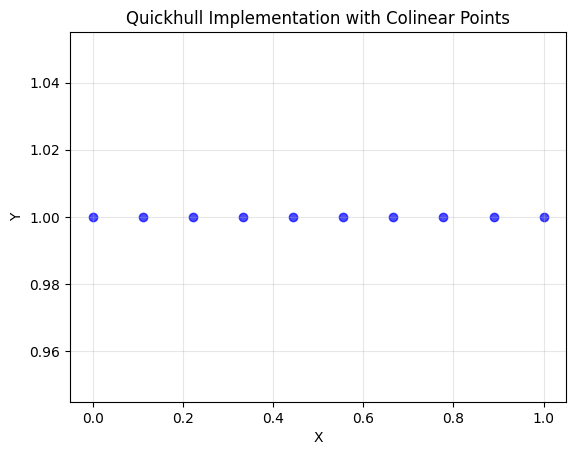

In [252]:
convex_hull = quickhull(colinear_points)
convex_x = [p[0] for p in convex_hull]
convex_y = [p[1] for p in convex_hull]
convex_x.append(convex_x[0])
convex_y.append(convex_y[0])
print("The number of points processed is: " + str(len(convex_hull)))

plt.scatter([p[0] for p in colinear_points], [p[1] for p in colinear_points], alpha = 0.7, color = "blue")
plt.plot(convex_x, convex_y, color = "red")
plt.title("Quickhull Implementation with Colinear Points")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha = 0.3)
plt.show()    

*You can see there is no convex hull being created as all points are on the same line.*

**The algorithm may also struggle to function in higher dimensions, as it has to process an entire planes of points instead of just a 2D area.**